# Práctico 1: EDA y Visualización

## Objetivo
Explorar los datos de adopción de IA para: 
1. Entender su estructura y calidad.
2. Describir variables clave de manera univariada.
3. Analizar relaciones bivariadas relevantes para el proyecto.
4. Formular hipóesis de investigación para los próximos prácticos.

## 1) Importación de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import plotly.express as px

sns.set_theme(style="whitegrid")


## 2) Carga de datos

Esta celda carga los tres archivos provistos en `data/raw/`:
- `ai_company_adoption.csv`
- `ai_industry_summary.csv`
- `country_ai_index.csv`

Usamos rutas relativas desde la carpeta `notebook/` para facilitar portabilidad del proyecto.
Finalmente, mostramos las dimensiones iniciales para validar que la lectura fue correcta.

In [2]:
company = pd.read_csv('../data/raw/ai_company_adoption.csv')
industry = pd.read_csv('../data/raw/ai_industry_summary.csv')
country = pd.read_csv('../data/raw/country_ai_index.csv')

print('company:', company.shape)
print('industry:', industry.shape)
print('country:', country.shape)


company: (150025, 43)
industry: (9, 8)
country: (30, 8)


### Dataset principal

In [3]:
company.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150025 entries, 0 to 150024
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150025 non-null  int64  
 1   company_id                   150025 non-null  object 
 2   survey_year                  150024 non-null  float64
 3   quarter                      150025 non-null  object 
 4   country                      150024 non-null  object 
 5   region                       150024 non-null  object 
 6   industry                     147772 non-null  object 
 7   company_size                 147774 non-null  object 
 8   num_employees                150025 non-null  float64
 9   annual_revenue_usd_millions  147778 non-null  float64
 10  company_founding_year        150025 non-null  float64
 11  company_age                  150025 non-null  float64
 12  company_age_group            150024 non-null  object 
 13 

### Interpretación tentativa de las columnas de `company`

Las siguientes descripciones son la mejor interpretación posible a partir de los nombres de las variables y de los resultados observados en la notebook. Como no se dispone de un diccionario de datos, generamos suposiciones educadas acerca del contenido de cada variable.

| Columna | Contenido probable |
|---|---|
| `response_id` | Identificador único de cada respuesta o registro de la encuesta. |
| `company_id` | Identificador de la empresa; puede repetirse si una misma compañía fue observada en distintos períodos. Para muchas empresas, existen hasta 16 observaciones: una por cada Q del año, durante cuatro años |
| `survey_year` | Año calendario en que se realizó la observación o encuesta. |
| `quarter` | Trimestre del año correspondiente a la observación, por ejemplo, Q1 a Q4. |
| `country` | País en el que se ubica o se registra la empresa encuestada. |
| `region` | Región geográfica más amplia a la que pertenece el país. |
| `industry` | Sector o industria principal en que opera la empresa. |
| `company_size` | Categoría de tamaño de la empresa, como startup, pyme o gran empresa. |
| `num_employees` | Cantidad de personas empleadas por la compañía. |
| `annual_revenue_usd_millions` | Facturación o ingresos anuales de la empresa, expresados en millones de dólares estadounidenses. |
| `company_founding_year` | Año de fundación de la empresa. |
| `company_age` | Antigüedad de la empresa en años al momento de la observación. |
| `company_age_group` | Rango categórico de antigüedad de la empresa. |
| `ai_adoption_rate` | Porcentaje o índice que estima el grado de adopción de IA en la empresa. Aunque parece expresado como porcentaje, se observan valores fuera del rango 0–100 que requieren validación. |
| `ai_adoption_stage` | Etapa de adopción de IA: sin adopción, piloto, adopción parcial o adopción completa. |
| `years_using_ai` | Cantidad de años que la empresa lleva utilizando tecnologías de IA. |
| `ai_primary_tool` | Herramienta o plataforma de IA utilizada principalmente por la empresa. |
| `num_ai_tools_used` | Número de herramientas de IA distintas que utiliza la empresa. |
| `ai_use_case` | Principal caso de uso o área funcional en la que se aplica IA. |
| `ai_projects_active` | Cantidad de proyectos de IA actualmente activos. |
| `ai_training_hours` | Horas dedicadas a capacitación en IA; la población o período de referencia no están especificados. |
| `ai_budget_percentage` | Porcentaje del presupuesto de la empresa asignado a iniciativas de IA. |
| `ai_maturity_score` | Puntaje sintético de madurez de la empresa en el uso de IA; por los resultados parece estar normalizado entre 0 y 1. |
| `ai_failure_rate` | Porcentaje estimado de proyectos o iniciativas de IA que no alcanzaron sus objetivos. |
| `ai_investment_per_employee` | Inversión monetaria en IA por empleado, probablemente expresada en dólares estadounidenses. |
| `regulatory_compliance_score` | Puntaje que refleja el nivel de cumplimiento de normas y regulaciones vinculadas con IA. |
| `data_privacy_level` | Nivel categórico de protección o madurez en privacidad de datos. |
| `ai_ethics_committee` | Indica si la empresa cuenta con un comité de ética para temas de IA. |
| `ai_risk_management_score` | Puntaje de capacidad o madurez para gestionar riesgos asociados con la IA. |
| `remote_work_percentage` | Porcentaje de trabajo o de empleados bajo modalidad remota. |
| `employee_satisfaction_score` | Puntaje de satisfacción de los empleados. |
| `task_automation_rate` | Porcentaje de tareas automatizadas, probablemente mediante IA. |
| `time_saved_per_week` | Horas de trabajo ahorradas por semana gracias a la IA; la unidad de análisis exacta no está especificada. |
| `productivity_change_percent` | Variación porcentual de la productividad, presumiblemente después de adoptar IA. Puede ser negativa si la productividad disminuyó. |
| `jobs_displaced` | Cantidad de puestos de trabajo desplazados o eliminados atribuibles a la adopción de IA. |
| `jobs_created` | Cantidad de nuevos puestos de trabajo creados en relación con la adopción de IA. |
| `reskilled_employees` | Cantidad de empleados recapacitados o reconvertidos para desempeñar nuevas funciones. |
| `revenue_growth_percent` | Crecimiento porcentual de los ingresos, posiblemente asociado con el uso de IA. |
| `cost_reduction_percent` | Reducción porcentual de costos, posiblemente atribuida a la adopción de IA. |
| `innovation_score` | Puntaje que resume el nivel o la capacidad de innovación de la empresa. |
| `customer_satisfaction` | Puntaje de satisfacción de los clientes. |
| `survey_source` | Fuente, estudio o institución de la que proviene la información. |
| `data_collection_method` | Método utilizado para recolectar los datos, como entrevista, encuesta o recopilación mediante API. |

### Datasets complementarios

**`industry`** es una **derivación del dataset principal**: todas sus columnas
  (`avg_ai_adoption_rate`, `avg_productivity_change_percent`, etc.) son promedios
  calculados agrupando `company` por industria. No aporta información nueva, sino un
  resumen agregado de datos que ya están en la tabla principal.

In [4]:
industry.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   industry                         9 non-null      object 
 1   avg_ai_adoption_rate             9 non-null      float64
 2   avg_productivity_change_percent  9 non-null      float64
 3   avg_ai_maturity_score            9 non-null      float64
 4   avg_ai_failure_rate              9 non-null      float64
 5   avg_jobs_displaced               9 non-null      float64
 6   avg_jobs_created                 9 non-null      float64
 7   avg_customer_satisfaction        9 non-null      float64
dtypes: float64(7), object(1)
memory usage: 708.0+ bytes


**`country`** funciona como una **tabla de contexto externo**: incorpora
  indicadores macro del país (PBI per cápita, madurez digital, patentes e
  investigadores de IA) que *no* derivan de `company` y que enriquecen el análisis a
  nivel país.

In [5]:
country.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     30 non-null     object 
 1   region                      30 non-null     object 
 2   gdp_per_capita              30 non-null     float64
 3   internet_penetration        30 non-null     float64
 4   digital_maturity_index      30 non-null     float64
 5   country_ai_policy           30 non-null     object 
 6   ai_patent_filings_2024      30 non-null     int64  
 7   ai_researchers_per_million  30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


En base al análisis rápido realizado, podemos concluir que las bases están compuestas de la siguiente manera:
`company`: microdatos a nivel empresa/respuesta (archivo principal del análisis).
`industry`: resumen agregado por industria (útil para contraste).
`country`: contexto país (madurez digital, I+D, políticas, etc.).


## 3) Descripción general y clasificación de variables

### ¿Cuántos registros y variables tiene cada archivo?

Primero se resume la dimensión de cada dataset. Luego se clasifica cada columna según su **función analítica**, no solamente según el tipo técnico que informa pandas.

Esta distinción es importante porque una columna almacenada como número no siempre representa una medida cuantitativa. Por ejemplo, un identificador o un año pueden tener `dtype` numérico, pero no corresponde calcular promedios o desviaciones sobre ellos.

### Criterios de clasificación utilizados

- **Identificador**: distingue registros o entidades. Se usa para validar unicidad, relacionar tablas o rastrear observaciones; no como variable explicativa.
- **Temporal**: representa años, trimestres u otros períodos.
- **Categórica nominal**: contiene categorías sin un orden natural.
- **Categórica ordinal**: contiene categorías con un orden conceptual.
- **Categórica binaria**: admite dos estados posibles.
- **Numérica discreta**: representa conteos o cantidades enteras.
- **Numérica continua**: representa tasas, porcentajes, puntajes, importes o mediciones.


#### Clasificación por tipo analítico

Primero se define el rol analítico de cada variable. Esta clasificación complementa
el tipo de dato de pandas y distingue identificadores, variables categóricas,
numéricas y temporales.

Una **variable categórica binaria** presenta exactamente dos estados posibles y
**mutuamente excluyentes**. En cambio, las variables categóricas nominales agrupan
categorías sin asumir un orden inherente entre ellas.


In [6]:
# -------------------------------------------------------------------------
# CLASIFICACIÓN SEMÁNTICA DE LAS VARIABLES
# -------------------------------------------------------------------------
# El dtype de pandas describe cómo está almacenada una columna, pero no
# necesariamente cómo debe interpretarse en el análisis. Por eso se define
# manualmente el rol analítico de cada variable de los tres datasets.

reglas_clasificacion = {
    'company': {
        'Identificador': [
            'response_id', 'company_id'
        ],
        'Temporal': [
            'survey_year', 'quarter', 'company_founding_year'
        ],
        'Categórica nominal': [
            'country', 'region', 'industry', 'company_size',
            'ai_primary_tool', 'ai_use_case', 'survey_source',
            'data_collection_method'
        ],
        'Categórica ordinal': [
            'company_age_group', 'ai_adoption_stage',
            'data_privacy_level'
        ],
        'Categórica binaria': [
            'ai_ethics_committee'
        ],
        'Numérica discreta': [
            'num_employees', 'company_age', 'years_using_ai',
            'num_ai_tools_used', 'ai_projects_active', 'jobs_displaced',
            'jobs_created', 'reskilled_employees'
        ],
        'Numérica continua': [
            'annual_revenue_usd_millions', 'ai_adoption_rate',
            'ai_training_hours', 'ai_budget_percentage', 'ai_maturity_score',
            'ai_failure_rate', 'ai_investment_per_employee',
            'regulatory_compliance_score', 'ai_risk_management_score',
            'remote_work_percentage', 'employee_satisfaction_score',
            'task_automation_rate', 'time_saved_per_week',
            'productivity_change_percent', 'revenue_growth_percent',
            'cost_reduction_percent', 'innovation_score',
            'customer_satisfaction'
        ],
    },
    'industry': {
        'Categórica nominal': [
            'industry'
        ],
        'Numérica continua': [
            'avg_ai_adoption_rate', 'avg_productivity_change_percent',
            'avg_ai_maturity_score', 'avg_ai_failure_rate',
            'avg_jobs_displaced', 'avg_jobs_created',
            'avg_customer_satisfaction'
        ],
    },
    'country': {
        # "country" funciona como clave de unión y también como categoría geográfica.
        'Identificador': [
            'country'
        ],
        'Categórica nominal': [
            'region', 'country_ai_policy'
        ],
        'Numérica discreta': [
            'ai_patent_filings_2024'
        ],
        'Numérica continua': [
            'gdp_per_capita', 'internet_penetration',
            'digital_maturity_index', 'ai_researchers_per_million'
        ],
    },
}


#### Clasificación temática

También se agrupan las variables según la pregunta que ayudan a responder: contexto
organizacional, adopción de IA, gobernanza, impacto y metadatos de la encuesta.


In [7]:
# -------------------------------------------------------------------------
# CLASIFICACIÓN TEMÁTICA (por "tipo de pregunta" que responde la variable)
# -------------------------------------------------------------------------
# A diferencia de la clasificación por tipo de dato (identificador, categórica,
# numérica...), acá agrupamos según DE QUÉ trata la respuesta. Las variables
# cuentan una historia en cadena: quién es la empresa (contexto) -> cuánto
# adoptó IA (adopción) -> qué le pasó como consecuencia (impacto).

clasificacion_tematica = {
    'company': {
        'Identificación y tiempo': [
            'response_id', 'company_id', 'survey_year', 'quarter'
        ],
        'Contexto organizacional': [
            'country', 'region', 'industry', 'company_size', 'num_employees',
            'annual_revenue_usd_millions', 'company_founding_year',
            'company_age', 'company_age_group'
        ],
        'Adopción de IA': [
            'ai_adoption_rate', 'ai_adoption_stage', 'years_using_ai',
            'ai_primary_tool', 'num_ai_tools_used', 'ai_use_case',
            'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
            'ai_maturity_score', 'ai_failure_rate', 'ai_investment_per_employee'
        ],
        'Gobernanza y riesgo': [
            'regulatory_compliance_score', 'data_privacy_level',
            'ai_ethics_committee', 'ai_risk_management_score'
        ],
        'Impacto laboral y de negocio': [
            'remote_work_percentage', 'employee_satisfaction_score',
            'task_automation_rate', 'time_saved_per_week',
            'productivity_change_percent', 'jobs_displaced', 'jobs_created',
            'reskilled_employees', 'revenue_growth_percent',
            'cost_reduction_percent', 'innovation_score', 'customer_satisfaction'
        ],
        'Metadata de la encuesta': [
            'survey_source', 'data_collection_method'
        ],
    },
    'industry': {
        'Contexto organizacional': ['industry'],
        'Adopción de IA': [
            'avg_ai_adoption_rate', 'avg_ai_maturity_score', 'avg_ai_failure_rate'
        ],
        'Impacto laboral y de negocio': [
            'avg_productivity_change_percent', 'avg_jobs_displaced',
            'avg_jobs_created', 'avg_customer_satisfaction'
        ],
    },
    'country': {
        # La tabla country es contexto macro del país donde opera la empresa;
        # todas sus variables responden "¿cómo es el entorno nacional?".
        'Contexto organizacional': [
            'country', 'region', 'gdp_per_capita', 'internet_penetration',
            'digital_maturity_index', 'country_ai_policy',
            'ai_patent_filings_2024', 'ai_researchers_per_million'
        ],
    },
}


#### Construcción de la clasificación

Las siguientes funciones validan que todas las columnas estén clasificadas y
construyen una tabla común para los tres datasets.


In [8]:
datasets = {
    'company': company,
    'industry': industry,
    'country': country,
}


def _mapa_validado(dataset_nombre, df, reglas, etiqueta):
    """
    Invierte un diccionario {clase: [columnas]} a {columna: clase}, validando
    que cada columna esté clasificada una sola vez y que no falte ni sobre
    ninguna respecto de las columnas reales del dataset.
    """
    variable_a_clase = {}

    for clase, columnas in reglas.items():
        for columna in columnas:
            if columna in variable_a_clase:
                raise ValueError(
                    f"La variable '{columna}' fue clasificada más de una vez "
                    f"en el dataset '{dataset_nombre}' ({etiqueta})."
                )
            variable_a_clase[columna] = clase

    columnas_reales = set(df.columns)
    columnas_clasificadas = set(variable_a_clase)

    faltantes_en_reglas = sorted(columnas_reales - columnas_clasificadas)
    inexistentes_en_dataset = sorted(columnas_clasificadas - columnas_reales)

    if faltantes_en_reglas or inexistentes_en_dataset:
        raise ValueError(
            f"Clasificación {etiqueta} incompleta para '{dataset_nombre}'. "
            f"Sin clasificar: {faltantes_en_reglas}. "
            f"No encontradas en el dataset: {inexistentes_en_dataset}."
        )

    return variable_a_clase


def construir_clasificacion(dataset_nombre, df, reglas, reglas_tema):
    """
    Construye una fila por variable con:
    - tipo técnico de pandas;
    - clasificación analítica (por tipo de dato);
    - clasificación temática (por tipo de pregunta);
    - cantidad y porcentaje de valores faltantes;
    - cardinalidad (cantidad de valores distintos).

    También valida que cada columna haya sido clasificada una sola vez en
    ambas clasificaciones.
    """
    variable_a_clase = _mapa_validado(
        dataset_nombre, df, reglas, 'tipo de dato'
    )
    variable_a_tema = _mapa_validado(
        dataset_nombre, df, reglas_tema, 'temática'
    )

    filas = []
    for columna in df.columns:
        cantidad_nulos = int(df[columna].isna().sum())

        filas.append({
            'dataset': dataset_nombre,
            'variable': columna,
            'dtype_pandas': str(df[columna].dtype),
            'clasificacion_analitica': variable_a_clase[columna],
            'clasificacion_pregunta': variable_a_tema[columna],
            'valores_unicos': int(df[columna].nunique(dropna=True)),
            'nulos': cantidad_nulos,
            'porcentaje_nulos': round(cantidad_nulos / len(df) * 100, 2),
        })

    return pd.DataFrame(filas)


# Se genera una única tabla de clasificación para los tres archivos.
clasificacion_variables = pd.concat(
    [
        construir_clasificacion(
            nombre,
            df,
            reglas_clasificacion[nombre],
            clasificacion_tematica[nombre]
        )
        for nombre, df in datasets.items()
    ],
    ignore_index=True
)


#### Resumen de dimensiones y variables

Finalmente se presentan el resumen por dataset y la clasificación detallada de cada
variable.


In [9]:
# Resumen técnico y semántico por dataset.
resumen_dimensiones = pd.DataFrame({
    'dataset': list(datasets.keys()),
    'rows': [len(df) for df in datasets.values()],
    'columns': [df.shape[1] for df in datasets.values()],
    'numeric_vars_dtype': [
        df.select_dtypes(include='number').shape[1]
        for df in datasets.values()
    ],
    'non_numeric_vars_dtype': [
        df.select_dtypes(exclude='number').shape[1]
        for df in datasets.values()
    ],
})

resumen_semantico = (
    clasificacion_variables
    .pivot_table(
        index='dataset',
        columns='clasificacion_analitica',
        values='variable',
        aggfunc='count',
        fill_value=0
    )
    .reset_index()
)

summary = resumen_dimensiones.merge(resumen_semantico, on='dataset', how='left')

print('Resumen de dimensiones y tipos de variables:')
display(summary)

print('\nClasificación detallada de todas las variables:')
display(clasificacion_variables)


Resumen de dimensiones y tipos de variables:


,dataset,rows,columns,numeric_vars_dtype,non_numeric_vars_dtype,Categórica binaria,Categórica nominal,Categórica ordinal,Identificador,Numérica continua,Numérica discreta,Temporal
0,company,150025,43,29,14,1,8,3,2,18,8,3
1,industry,9,8,7,1,0,1,0,0,7,0,0
2,country,30,8,5,3,0,2,0,1,4,1,0



Clasificación detallada de todas las variables:


,dataset,variable,dtype_pandas,clasificacion_analitica,clasificacion_pregunta,valores_unicos,nulos,porcentaje_nulos
0,company,response_id,int64,Identificador,Identificación y tiempo,150025,0,0.0
1,company,company_id,object,Identificador,Identificación y tiempo,10025,0,0.0
2,company,survey_year,float64,Temporal,Identificación y tiempo,4,1,0.0
3,company,quarter,object,Temporal,Identificación y tiempo,4,0,0.0
4,company,country,object,Categórica nominal,Contexto organizacional,30,1,0.0
5,company,region,object,Categórica nominal,Contexto organizacional,6,1,0.0
6,company,industry,object,Categórica nominal,Contexto organizacional,9,2253,1.5
7,company,company_size,object,Categórica nominal,Contexto organizacional,3,2251,1.5
8,company,num_employees,float64,Numérica discreta,Contexto organizacional,2850,0,0.0
9,company,annual_revenue_usd_millions,float64,Numérica continua,Contexto organizacional,8994,2247,1.5


### ¿Qué representa cada archivo y cómo se relacionan entre sí?

#### Relaciones entre datasets

Los tres archivos no están sueltos: se conectan entre sí formando lo que se conoce como
**esquema tipo estrella**. En el centro está `company`, la tabla principal, donde cada
fila representa a una empresa en un trimestre determinado (por ejemplo, "Empresa X en el
segundo trimestre de 2024"). Alrededor, las otras dos tablas aportan información de
contexto que se "engancha" a la principal.

Pensémoslo como una ficha de cada empresa a la que le podemos sumar datos externos:

- **`industry`** se conecta a través de la columna `industry`. Cada empresa pertenece a
  una industria (Tecnología, Finanzas, Salud, etc.), y esta tabla agrega el "resumen"
  de esa industria. Es como mirar la ficha de una empresa de Salud y poder consultar,
  al lado, cómo le va en promedio a *todo* el rubro salud.

- **`country`** se conecta a través de la columna `country` (y también `region`). Cada
  empresa opera en un país, y esta tabla suma indicadores de ese país (nivel de
  desarrollo digital, inversión en IA, etc.). Es como agregarle a la ficha de la empresa
  el "trasfondo" del país donde trabaja.

En términos prácticos, esta estructura permite **enriquecer** cada registro de la tabla
principal con información de su industria y de su país, sin tener que repetir esos datos
en cada fila. La columna que comparten (`industry` o `country`) es el "punto de unión"
que permite cruzar las tablas.

La celda siguiente verifica claves y relaciones lógicas:
- `company` se puede agregar por `industry` para comparar contra la tabla `industry`.
- `company` se puede agregar por `country` para conectar con la tabla `country`.

In [10]:
print('Industrias en company:', company['industry'].nunique())
print('Industrias en industry:', industry['industry'].nunique())
print('Paises en company:', company['country'].nunique())
print('Paises en country:', country['country'].nunique())

print('Industrias de industry que faltan en company:', set(industry['industry']) - set(company['industry'].dropna()))
print('Paises de country que faltan en company:', set(country['country']) - set(company['country'].dropna()))


Industrias en company: 9
Industrias en industry: 9
Paises en company: 30
Paises en country: 30
Industrias de industry que faltan en company: set()
Paises de country que faltan en company: set()


Estas parecen buenas noticias! Todas las observaciones que están en las tablas agregadas también se encuentran en la tabla de compañías. Coinciden los datos de los diferentes datasets.

### 3.1) Limpieza y control de calidad de los datos

La limpieza se realiza sobre copias llamadas `company_limpio`, `industry_limpio` y `country_limpio`. Los datasets originales se conservan sin cambios para no modificar los análisis ya desarrollados en las secciones siguientes.

El procedimiento aplica criterios conservadores y trazables:

1. Normaliza espacios y representaciones textuales de valores faltantes.
2. Convierte a formato numérico las columnas que deberían contener números.
3. Elimina únicamente filas completamente duplicadas.
4. Reemplaza por valores faltantes solo aquellos datos que incumplen límites lógicos claros.
5. Registra inconsistencias que requieren revisión, sin corregirlas arbitrariamente.
6. No imputa valores faltantes de forma general, porque cada variable y cada análisis requieren una decisión específica.

No se restringen variables como `productivity_change_percent` o `revenue_growth_percent`, ya que pueden ser negativas o superar el 100 % dependiendo del fenómeno medido.


In [11]:
# -------------------------------------------------------------------------
# LIMPIEZA DE DATOS
# -------------------------------------------------------------------------
# La función devuelve una copia limpia y dos reportes:
# 1) resumen general de los cambios aplicados;
# 2) detalle de incidencias detectadas por cada regla de calidad.
#
# Importante: no se incluye "none" entre los marcadores genéricos de faltante,
# porque en ai_adoption_stage es una categoría válida del dataset.

VALORES_FALTANTES_TEXTO = {
    '', 'na', 'n/a', 'nan', 'null', 'missing', '-'
}


#### Función de limpieza

La función centraliza la normalización de faltantes, la conversión de tipos, la
eliminación de duplicados y la aplicación de reglas de rango, sin modificar los
DataFrames originales.


In [12]:
def limpiar_dataset(
    df,
    nombre_dataset,
    columnas_numericas,
    reglas_rango=None,
    identificador_unico=None
):
    """
    Limpia un dataset sin aplicar imputaciones automáticas.

    Parámetros
    ----------
    df : pandas.DataFrame
        Dataset original.
    nombre_dataset : str
        Nombre utilizado en los reportes.
    columnas_numericas : list[str]
        Columnas que deberían contener valores numéricos.
    reglas_rango : dict, opcional
        Reglas de la forma:
        {'columna': {'min': valor_minimo, 'max': valor_maximo}}
        Los valores fuera de rango se reemplazan por pd.NA.
    identificador_unico : str, opcional
        Columna cuya unicidad debería verificarse.

    Retorna
    -------
    limpio : pandas.DataFrame
        Copia depurada.
    resumen : dict
        Métricas generales antes y después de limpiar.
    incidencias : list[dict]
        Reglas aplicadas y cantidad de casos detectados.
    """
    reglas_rango = reglas_rango or {}
    limpio = df.copy(deep=True)
    incidencias = []

    filas_iniciales = len(limpio)
    nulos_iniciales = int(limpio.isna().sum().sum())

    # ------------------------------------------------------------------
    # 1. Normalización de variables de texto
    # ------------------------------------------------------------------
    # Se eliminan espacios al inicio/final y se reducen espacios internos.
    # Las cadenas que representan ausencia de información pasan a pd.NA.
    columnas_texto = limpio.select_dtypes(
        include=['object', 'string', 'category']
    ).columns

    for columna in columnas_texto:
        serie_original = limpio[columna]
        serie_limpia = (
            serie_original
            .astype('string')
            .str.strip()
            .str.replace(r'\s+', ' ', regex=True)
        )

        mascara_faltantes_texto = (
            serie_limpia.str.lower().isin(VALORES_FALTANTES_TEXTO)
        )
        nuevos_nulos = int(
            mascara_faltantes_texto.fillna(False).sum()
        )

        limpio[columna] = serie_limpia.mask(mascara_faltantes_texto, pd.NA)

        if nuevos_nulos > 0:
            incidencias.append({
                'dataset': nombre_dataset,
                'regla': 'Texto vacío o marcador de faltante',
                'variable': columna,
                'casos_detectados': nuevos_nulos,
                'accion': 'Reemplazados por pd.NA',
            })

    # ------------------------------------------------------------------
    # 2. Conversión controlada de columnas numéricas
    # ------------------------------------------------------------------
    # errors="coerce" evita que valores textuales inválidos provoquen un
    # error de ejecución. Esos casos se transforman en valores faltantes
    # y quedan registrados en el reporte.
    for columna in columnas_numericas:
        no_nulos_antes = int(limpio[columna].notna().sum())
        convertida = pd.to_numeric(limpio[columna], errors='coerce')
        no_nulos_despues = int(convertida.notna().sum())
        conversiones_invalidas = no_nulos_antes - no_nulos_despues

        limpio[columna] = convertida

        if conversiones_invalidas > 0:
            incidencias.append({
                'dataset': nombre_dataset,
                'regla': 'Conversión numérica',
                'variable': columna,
                'casos_detectados': conversiones_invalidas,
                'accion': 'Valores no convertibles reemplazados por pd.NA',
            })

    # ------------------------------------------------------------------
    # 3. Eliminación de duplicados exactos
    # ------------------------------------------------------------------
    # Solo se eliminan filas idénticas en todas las columnas. No se decide
    # automáticamente entre registros diferentes que compartan un ID.
    duplicados_exactos = int(limpio.duplicated().sum())
    if duplicados_exactos > 0:
        limpio = limpio.drop_duplicates().copy()
        incidencias.append({
            'dataset': nombre_dataset,
            'regla': 'Filas completamente duplicadas',
            'variable': 'todas',
            'casos_detectados': duplicados_exactos,
            'accion': 'Filas duplicadas eliminadas',
        })

    # ------------------------------------------------------------------
    # 4. Validación de identificadores
    # ------------------------------------------------------------------
    # Un ID repetido no se elimina automáticamente, porque podría requerir
    # criterios adicionales para decidir qué registro conservar.
    if identificador_unico is not None:
        ids_duplicados = int(
            limpio[identificador_unico]
            .duplicated(keep=False)
            .sum()
        )

        if ids_duplicados > 0:
            incidencias.append({
                'dataset': nombre_dataset,
                'regla': 'Identificador repetido',
                'variable': identificador_unico,
                'casos_detectados': ids_duplicados,
                'accion': 'Solo informado; requiere revisión manual',
            })

    # ------------------------------------------------------------------
    # 5. Validación de rangos lógicos
    # ------------------------------------------------------------------
    # Solo se corrigen límites inequívocos. No se aplica winsorización ni
    # eliminación por IQR, porque un valor extremo no necesariamente es
    # erróneo y podría contener información relevante.
    for columna, limites in reglas_rango.items():
        mascara_invalida = pd.Series(False, index=limpio.index)

        if limites.get('min') is not None:
            mascara_invalida |= limpio[columna] < limites['min']

        if limites.get('max') is not None:
            mascara_invalida |= limpio[columna] > limites['max']

        cantidad_invalidos = int(mascara_invalida.fillna(False).sum())

        if cantidad_invalidos > 0:
            limpio.loc[mascara_invalida, columna] = pd.NA
            incidencias.append({
                'dataset': nombre_dataset,
                'regla': (
                    f"Rango válido: {limites.get('min', '-∞')} "
                    f"a {limites.get('max', '∞')}"
                ),
                'variable': columna,
                'casos_detectados': cantidad_invalidos,
                'accion': 'Valores fuera de rango reemplazados por pd.NA',
            })

    resumen = {
        'dataset': nombre_dataset,
        'filas_iniciales': filas_iniciales,
        'filas_finales': len(limpio),
        'duplicados_exactos_eliminados': duplicados_exactos,
        'nulos_iniciales': nulos_iniciales,
        'nulos_finales': int(limpio.isna().sum().sum()),
    }

    return limpio, resumen, incidencias


#### Columnas numéricas y reglas de rango

Se declaran explícitamente las columnas numéricas y solo se aplican límites lógicos
claros, de modo que las correcciones sean conservadoras y trazables.


In [13]:
# Columnas cuyo contenido debería ser numérico.
columnas_numericas_company = [
    'response_id', 'survey_year', 'num_employees',
    'annual_revenue_usd_millions', 'company_founding_year', 'company_age',
    'ai_adoption_rate', 'years_using_ai', 'num_ai_tools_used',
    'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
    'ai_maturity_score', 'ai_failure_rate',
    'ai_investment_per_employee', 'regulatory_compliance_score',
    'ai_risk_management_score', 'remote_work_percentage',
    'employee_satisfaction_score', 'task_automation_rate',
    'time_saved_per_week', 'productivity_change_percent',
    'jobs_displaced', 'jobs_created', 'reskilled_employees',
    'revenue_growth_percent', 'cost_reduction_percent',
    'innovation_score', 'customer_satisfaction'
]

columnas_numericas_industry = [
    'avg_ai_adoption_rate', 'avg_productivity_change_percent',
    'avg_ai_maturity_score', 'avg_ai_failure_rate',
    'avg_jobs_displaced', 'avg_jobs_created',
    'avg_customer_satisfaction'
]

columnas_numericas_country = [
    'gdp_per_capita', 'internet_penetration',
    'digital_maturity_index', 'ai_patent_filings_2024',
    'ai_researchers_per_million'
]


# Reglas conservadoras: se incluyen únicamente límites lógicos claros.
reglas_rango_company = {
    'num_employees': {'min': 0},
    'annual_revenue_usd_millions': {'min': 0},
    'company_age': {'min': 0},
    'years_using_ai': {'min': 0},
    'num_ai_tools_used': {'min': 0},
    'ai_projects_active': {'min': 0},
    'ai_training_hours': {'min': 0},
    'ai_investment_per_employee': {'min': 0},
    'time_saved_per_week': {'min': 0},
    'jobs_displaced': {'min': 0},
    'jobs_created': {'min': 0},
    'reskilled_employees': {'min': 0},
    'ai_adoption_rate': {'min': 0, 'max': 100},
    'ai_budget_percentage': {'min': 0, 'max': 100},
    'remote_work_percentage': {'min': 0, 'max': 100},
    'task_automation_rate': {'min': 0, 'max': 100},
    'ai_maturity_score': {'min': 0, 'max': 1},
}

reglas_rango_industry = {
    'avg_ai_adoption_rate': {'min': 0, 'max': 100},
    'avg_ai_maturity_score': {'min': 0, 'max': 1},
    'avg_jobs_displaced': {'min': 0},
    'avg_jobs_created': {'min': 0},
}

reglas_rango_country = {
    'gdp_per_capita': {'min': 0},
    'internet_penetration': {'min': 0, 'max': 100},
    'ai_patent_filings_2024': {'min': 0},
    'ai_researchers_per_million': {'min': 0},
}


#### Aplicación de la limpieza

Cada archivo se limpia de forma independiente y se conserva tanto el resumen como el
detalle de las incidencias detectadas.


In [14]:
# Se limpia cada archivo de manera independiente.
company_limpio, resumen_company, incidencias_company = limpiar_dataset(
    company,
    nombre_dataset='company',
    columnas_numericas=columnas_numericas_company,
    reglas_rango=reglas_rango_company,
    identificador_unico='response_id'
)

industry_limpio, resumen_industry, incidencias_industry = limpiar_dataset(
    industry,
    nombre_dataset='industry',
    columnas_numericas=columnas_numericas_industry,
    reglas_rango=reglas_rango_industry
)

country_limpio, resumen_country, incidencias_country = limpiar_dataset(
    country,
    nombre_dataset='country',
    columnas_numericas=columnas_numericas_country,
    reglas_rango=reglas_rango_country,
    identificador_unico='country'
)


#### Controles de consistencia entre variables

Estas verificaciones se informan, pero no se corrigen automáticamente, porque elegir
qué columna prevalece requiere conocer el proceso de generación de los datos.


In [15]:
# -------------------------------------------------------------------------
# 6. Controles de consistencia entre variables relacionadas
# -------------------------------------------------------------------------
# Estas inconsistencias se informan, pero no se corrigen automáticamente,
# porque elegir cuál columna es la correcta requiere conocimiento del origen.
mas_anios_ia_que_antiguedad = (
    company_limpio['years_using_ai'] > company_limpio['company_age']
).fillna(False)

fundacion_posterior_encuesta = (
    company_limpio['company_founding_year']
    > company_limpio['survey_year']
).fillna(False)

edad_calculada = (
    company_limpio['survey_year']
    - company_limpio['company_founding_year']
)

edad_inconsistente = (
    (company_limpio['company_age'] - edad_calculada).abs() > 1
).fillna(False)

controles_consistencia = [
    {
        'dataset': 'company',
        'regla': 'years_using_ai no debería superar company_age',
        'variable': 'years_using_ai / company_age',
        'casos_detectados': int(mas_anios_ia_que_antiguedad.sum()),
        'accion': 'Solo informado; requiere revisión',
    },
    {
        'dataset': 'company',
        'regla': 'company_founding_year no debería superar survey_year',
        'variable': 'company_founding_year / survey_year',
        'casos_detectados': int(fundacion_posterior_encuesta.sum()),
        'accion': 'Solo informado; requiere revisión',
    },
    {
        'dataset': 'company',
        'regla': 'company_age debe ser consistente con los años declarados',
        'variable': 'company_age / survey_year / company_founding_year',
        'casos_detectados': int(edad_inconsistente.sum()),
        'accion': 'Solo informado; se admite diferencia de hasta un año',
    },
]


#### Resultados de la limpieza

Los reportes permiten comprobar cuántos registros cambiaron, qué reglas se activaron
y cuáles son las variables con mayor proporción de faltantes.


In [16]:
# Reportes finales de limpieza.
reporte_limpieza = pd.DataFrame([
    resumen_company,
    resumen_industry,
    resumen_country,
])

incidencias_calidad = pd.DataFrame(
    incidencias_company
    + incidencias_industry
    + incidencias_country
    + controles_consistencia
)

print('Resumen de la limpieza:')
display(reporte_limpieza)

print('\nIncidencias detectadas y acciones aplicadas:')
display(incidencias_calidad)

print('\nVariables con mayor porcentaje de datos faltantes en company_limpio:')
display(
    company_limpio
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename('porcentaje_nulos')
    .head(10)
    .round(2)
    .to_frame()
)


Resumen de la limpieza:


,dataset,filas_iniciales,filas_finales,duplicados_exactos_eliminados,nulos_iniciales,nulos_finales
0,company,150025,150025,0,29270,30031
1,industry,9,9,0,0,0
2,country,30,30,0,0,0



Incidencias detectadas y acciones aplicadas:


,dataset,regla,variable,casos_detectados,accion
0,company,Rango válido: 0 a ∞,annual_revenue_usd_millions,160,Valores fuera de rango reemplazados por pd.NA
1,company,Rango válido: 0 a ∞,ai_training_hours,148,Valores fuera de rango reemplazados por pd.NA
2,company,Rango válido: 0 a ∞,ai_investment_per_employee,152,Valores fuera de rango reemplazados por pd.NA
3,company,Rango válido: 0 a 100,ai_adoption_rate,301,Valores fuera de rango reemplazados por pd.NA
4,company,years_using_ai no debería superar company_age,years_using_ai / company_age,0,Solo informado; requiere revisión
5,company,company_founding_year no debería superar surve...,company_founding_year / survey_year,0,Solo informado; requiere revisión
6,company,company_age debe ser consistente con los años ...,company_age / survey_year / company_founding_year,0,Solo informado; se admite diferencia de hasta ...



Variables con mayor porcentaje de datos faltantes en company_limpio:


,porcentaje_nulos
ai_adoption_rate,1.7
annual_revenue_usd_millions,1.6
ai_training_hours,1.6
industry,1.5
survey_source,1.5
customer_satisfaction,1.5
data_privacy_level,1.5
ai_primary_tool,1.5
company_size,1.5
ai_ethics_committee,1.5


A partir de este punto, los análisis utilizan `company_limpio`, `industry_limpio` y
`country_limpio` cuando corresponde. Los DataFrames originales permanecen disponibles
para comparaciones con los datos sin transformar.


### Verificación específica de `ai_adoption_stage = "none"`

Antes de interpretar `none` como ausencia de información, se contrasta esa categoría
con otras variables relacionadas con adopción de IA. El objetivo es distinguir una
**categoría válida** de un dato realmente faltante.


In [17]:
# Distribución original de la variable y perfil medio de la categoría "none".
stage_counts = (
    company['ai_adoption_stage']
    .value_counts(dropna=False)
    .rename_axis('ai_adoption_stage')
    .reset_index(name='registros')
)

display(stage_counts)

none_mask = (
    company_limpio['ai_adoption_stage']
    .astype('string')
    .str.lower()
    .eq('none')
)

perfil_none = (
    company_limpio.loc[
        none_mask,
        [
            'ai_adoption_rate',
            'years_using_ai',
            'ai_projects_active',
            'ai_maturity_score'
        ]
    ]
    .mean()
    .to_frame('media_en_none')
    .round(3)
)

display(perfil_none)

print(
    'NaN reales en ai_adoption_stage:',
    company_limpio['ai_adoption_stage'].isna().sum()
)


,ai_adoption_stage,registros
0,partial,78816
1,pilot,64323
2,none,5199
3,full,1686
4,NaN,1


,media_en_none
ai_adoption_rate,5.143
years_using_ai,0.000
ai_projects_active,2.176
ai_maturity_score,0.116


NaN reales en ai_adoption_stage: 1


La categoría `none` aparece en miles de registros y presenta, en promedio, una tasa
de adopción y una madurez de IA bajas, `years_using_ai = 0` y pocos proyectos activos.
Ese patrón es coherente con una etapa **sin adopción consolidada**, no con un faltante
en esa pregunta. Por lo tanto, `none` se conserva como categoría válida y no se
convierte a `NaN` ni a cero. El único valor originalmente ausente se mantiene como
dato faltante.


## 4) Análisis univariado

A continuación analizamos al menos cinco variables del archivo principal `company`:

1. `ai_adoption_rate` (numérica)
2. `ai_maturity_score` (numérica)
3. `productivity_change_percent` (numérica)
4. `industry` (categórica)
5. `company_size` (categórica)

Para las numéricas mostramos **histograma + boxplot** (forma, dispersión, asimetría y outliers).
Para categóricas mostramos **frecuencias relativas** (composición).

Además de los gráficos, cada celda imprime estadísticas básicas para respaldar la interpretación.

### Análisis de variables numéricas


#### Tasa de adopción de IA


count    147475.000000
mean         36.419684
std          14.541168
min           0.000000
25%          26.440000
50%          36.330000
75%          46.210000
max         100.000000
Name: ai_adoption_rate, dtype: float64


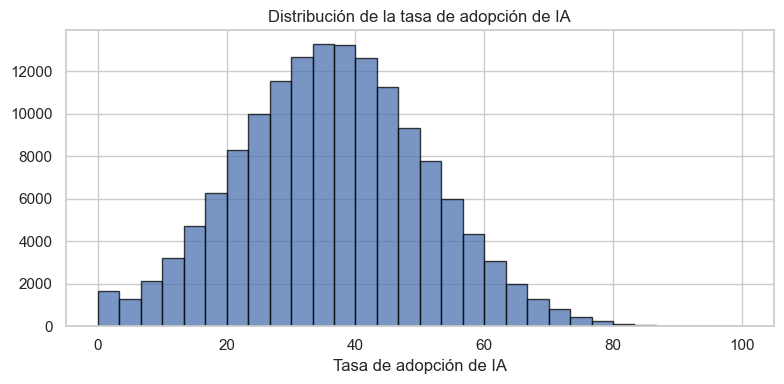

In [18]:
col = 'ai_adoption_rate'
print(company_limpio[col].describe())

plt.figure(figsize=(8, 4))
plt.hist(company_limpio[col].dropna(), bins=30, edgecolor='black', alpha=0.75)
plt.title('Distribución de la tasa de adopción de IA')
plt.xlabel('Tasa de adopción de IA')
plt.tight_layout()
plt.show()


La distribución es aproximadamente simétrica y se concentra alrededor de **36**: la
media es **36,42** y la mediana **36,33**. La cercanía entre ambas medidas indica que
no existe una asimetría marcada en la mayor parte de los datos.


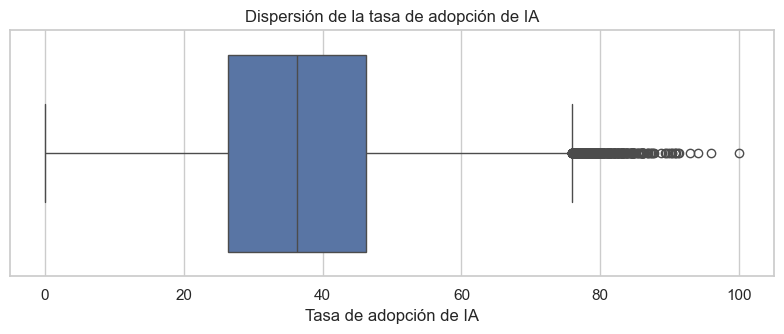

In [19]:
plt.figure(figsize=(8, 3.5))
sns.boxplot(x=company_limpio['ai_adoption_rate'], color='C0')
plt.title('Dispersión de la tasa de adopción de IA')
plt.xlabel('Tasa de adopción de IA')
plt.tight_layout()
plt.show()


El 50% central de los valores se encuentra entre **26,44** y **46,21**. La limpieza
convirtió en faltantes los registros fuera del rango lógico 0–100; los valores altos
que aún aparecen como extremos son observaciones válidas dentro de esa escala.


#### Madurez en IA


count    150025.000000
mean          0.344678
std           0.133817
min           0.000000
25%           0.250000
50%           0.341000
75%           0.435000
max           0.904000
Name: ai_maturity_score, dtype: float64


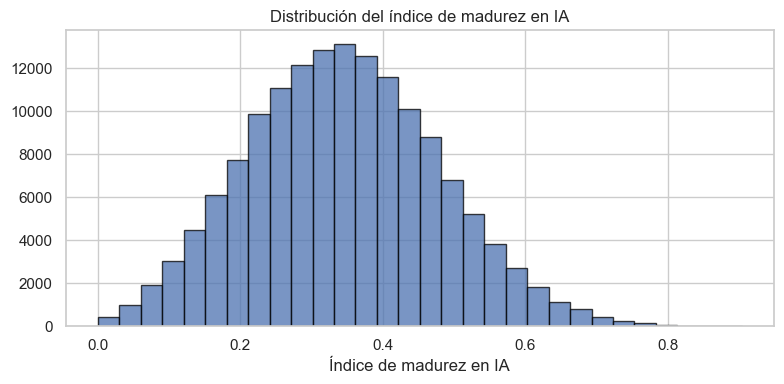

In [20]:
col = 'ai_maturity_score'
print(company_limpio[col].describe())

plt.figure(figsize=(8, 4))
plt.hist(company_limpio[col].dropna(), bins=30, edgecolor='black', alpha=0.75)
plt.title('Distribución del índice de madurez en IA')
plt.xlabel('Índice de madurez en IA')
plt.tight_layout()
plt.show()


El índice se concentra alrededor de **0,34** y presenta una forma aproximadamente
simétrica. La media (**0,345**) y la mediana (**0,341**) son muy similares.


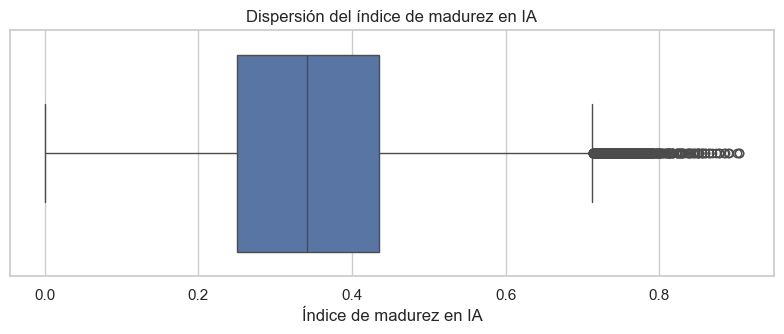

In [21]:
plt.figure(figsize=(8, 3.5))
sns.boxplot(x=company_limpio['ai_maturity_score'], color='C0')
plt.title('Dispersión del índice de madurez en IA')
plt.xlabel('Índice de madurez en IA')
plt.tight_layout()
plt.show()


La mitad central de los casos se ubica entre **0,250** y **0,435**, mientras que el
máximo alcanza **0,904**. Los pocos valores del extremo superior representan empresas
con una madurez considerablemente mayor que la mayoría.


#### Relación entre tasa de adopción y madurez en IA

Dado que `ai_adoption_rate` y `ai_maturity_score` tienen nombres y distribuciones
relacionadas, verificamos si podrían aportar información redundante.


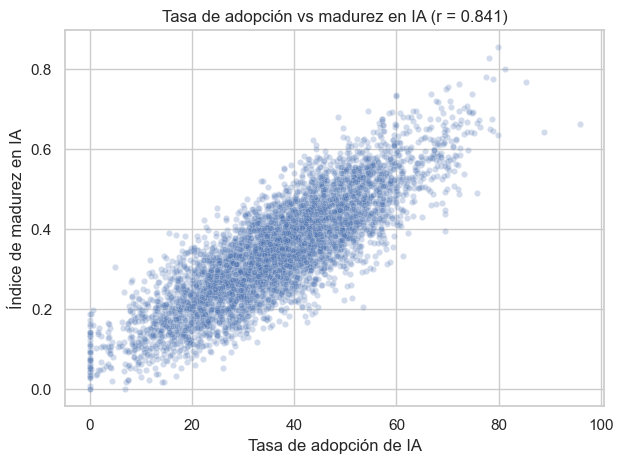

Correlación: 0.841


In [22]:
corr_adopcion_madurez = company_limpio[
    ['ai_adoption_rate', 'ai_maturity_score']
].corr().iloc[0, 1]

sns.scatterplot(
    data=company_limpio.sample(
        min(5000, len(company_limpio)),
        random_state=42
    ),
    x='ai_adoption_rate',
    y='ai_maturity_score',
    color='C0',
    alpha=0.25,
    s=20
)
plt.title(
    'Tasa de adopción vs madurez en IA '
    f'(r = {corr_adopcion_madurez:.3f})'
)
plt.xlabel('Tasa de adopción de IA')
plt.ylabel('Índice de madurez en IA')
plt.tight_layout()
plt.show()

print(f'Correlación: {corr_adopcion_madurez:.3f}')


Ambas variables están fuertemente asociadas, por lo que pueden contener información
parcialmente redundante. Sin embargo, conceptualmente no representan exactamente lo
mismo: `ai_adoption_rate` mide la extensión de la adopción, mientras que
`ai_maturity_score` resume un grado de madurez. En análisis posteriores convendrá
evaluar esta asociación antes de incluir ambas simultáneamente en un modelo.


#### Cambio porcentual en la productividad


count    150025.000000
mean          9.310881
std           6.368602
min         -57.053637
25%           5.060000
50%           9.060000
75%          13.130000
max         119.200258
Name: productivity_change_percent, dtype: float64


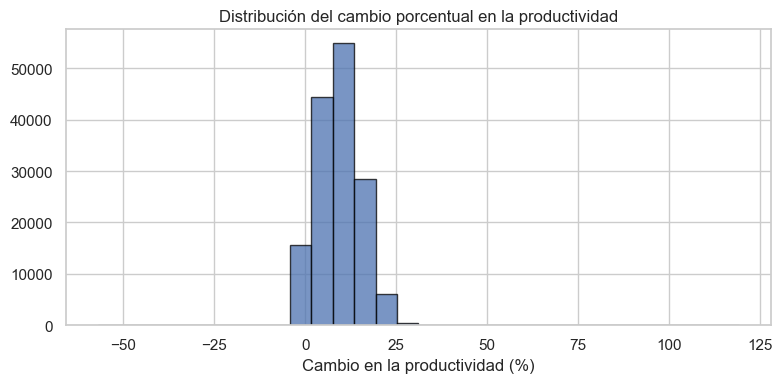

In [23]:
col = 'productivity_change_percent'
print(company_limpio[col].describe())

plt.figure(figsize=(8, 4))
plt.hist(company_limpio[col].dropna(), bins=30, edgecolor='black', alpha=0.75)
plt.title('Distribución del cambio porcentual en la productividad')
plt.xlabel('Cambio en la productividad (%)')
plt.tight_layout()
plt.show()


La mayor parte de las observaciones se concentra cerca de un aumento del **9%**: la
media es **9,31%** y la mediana **9,06%**. También existen cambios negativos y mejoras
muy superiores al nivel habitual.


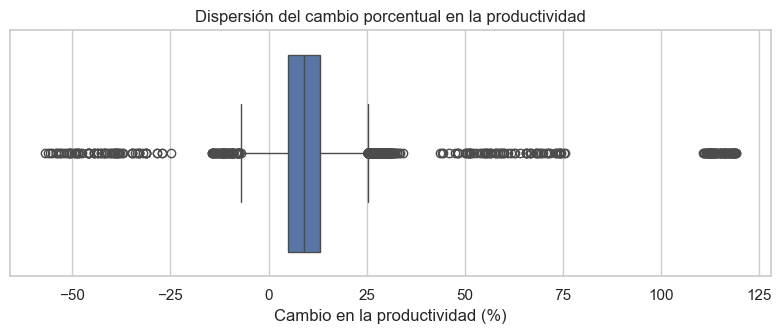

In [24]:
plt.figure(figsize=(8, 3.5))
sns.boxplot(x=company_limpio['productivity_change_percent'], color='C0')
plt.title('Dispersión del cambio porcentual en la productividad')
plt.xlabel('Cambio en la productividad (%)')
plt.tight_layout()
plt.show()


El 50% central está entre **5,06%** y **13,13%**, pero el rango completo va de
**−57,05%** a **119,20%**. El boxplot hace visibles observaciones extremas en ambas
direcciones, compatibles con caídas importantes o con aumentos superiores al 100%.


### Análisis de variables categóricas

La siguiente celda cubre dos variables categóricas con mayor impacto interpretativo:

- `industry`: permite identificar sectores más representados y contextualizar comparaciones.
- `company_size`: muestra composición por tamaño empresarial, importante porque puede sesgar niveles de inversión/adopción.

Usamos frecuencias normalizadas (`value_counts(normalize=True)`) para que la lectura sea porcentual y comparable.

In [25]:
def graficar_frecuencia_relativa(df, col):
    """Grafica la frecuencia relativa de las categorías observadas."""
    frecuencias = df[col].value_counts(dropna=True, normalize=True)

    plt.figure(figsize=(10, 4))
    sns.barplot(x=frecuencias.index, y=frecuencias.values, color='C0')
    plt.title(f'Frecuencia relativa de {col}')
    plt.gca().yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f'{y:.0%}')
    )
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, frecuencias.max() + 0.05)

    for i, value in enumerate(frecuencias.values):
        plt.text(i, value + 0.01, f'{value:.2%}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


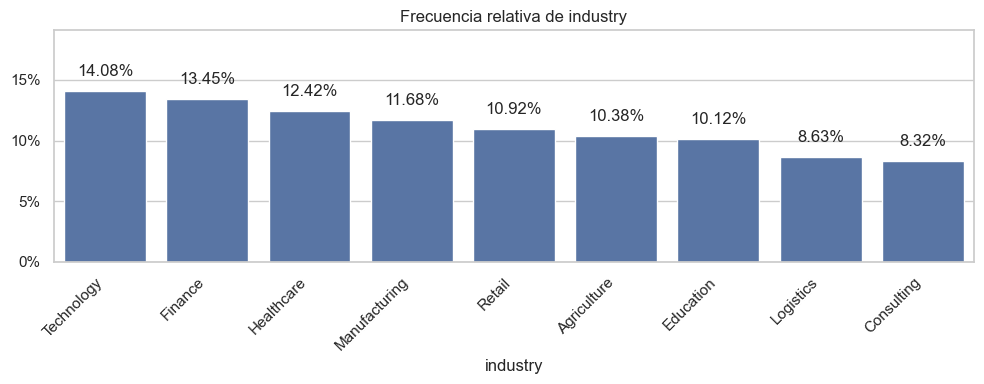

In [26]:
graficar_frecuencia_relativa(company_limpio, 'industry')


`Technology` es la industria con mayor representación, con **14,08%** de los
registros. La composición sectorial no es uniforme, por lo que las comparaciones entre
industrias deben considerar sus distintos tamaños muestrales.


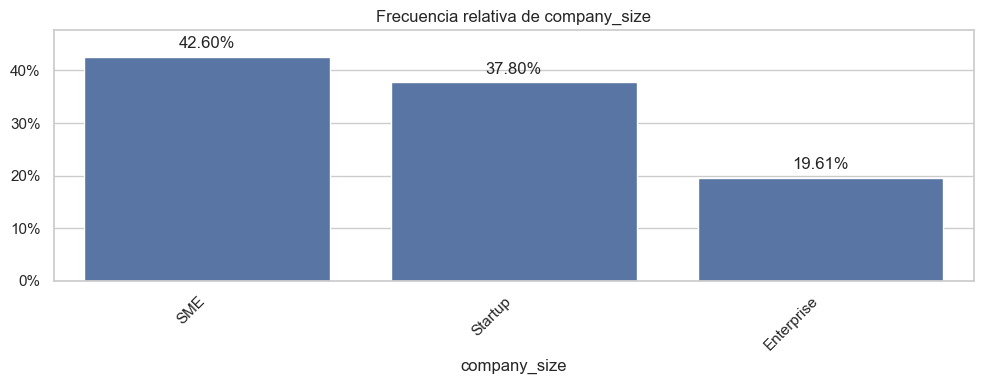

In [27]:
graficar_frecuencia_relativa(company_limpio, 'company_size')


Las empresas `SME` constituyen la categoría más frecuente, mientras que
`Enterprise` es la menos representada. Esta composición debe tenerse en cuenta al
comparar inversión o adopción entre tamaños, porque los grupos no tienen el mismo
peso en la muestra. El dataset permite describir esta diferencia, pero no determinar
por sí solo por qué hay menos empresas `Enterprise`.


## 5) Análisis bivariado y comparaciones

Aquí exploramos tres relaciones alineadas con la consigna, evitando mezclar períodos
temporales de una misma empresa como si fueran observaciones independientes:

1. **Adopción de IA por industria**
   - Se compara el último trimestre común y luego se analiza la evolución temporal.

2. **Inversión en IA vs cambio de productividad**
   - Se estudia el último trimestre disponible, se controla el overplotting y se
     evalúa si la concentración de inversiones bajas altera la asociación observada.

3. **Diferencias regionales y vínculo país-madurez digital**
   - Se compara la adopción por región y luego la relación entre madurez digital y
     adopción promedio por país, incorporando la dispersión dentro de cada país.


### Adopción de IA por industria

C:\Users\erics\AppData\Local\Temp\ipykernel_25232\2140253665.py:6: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  industry_df['period'] = pd.PeriodIndex(


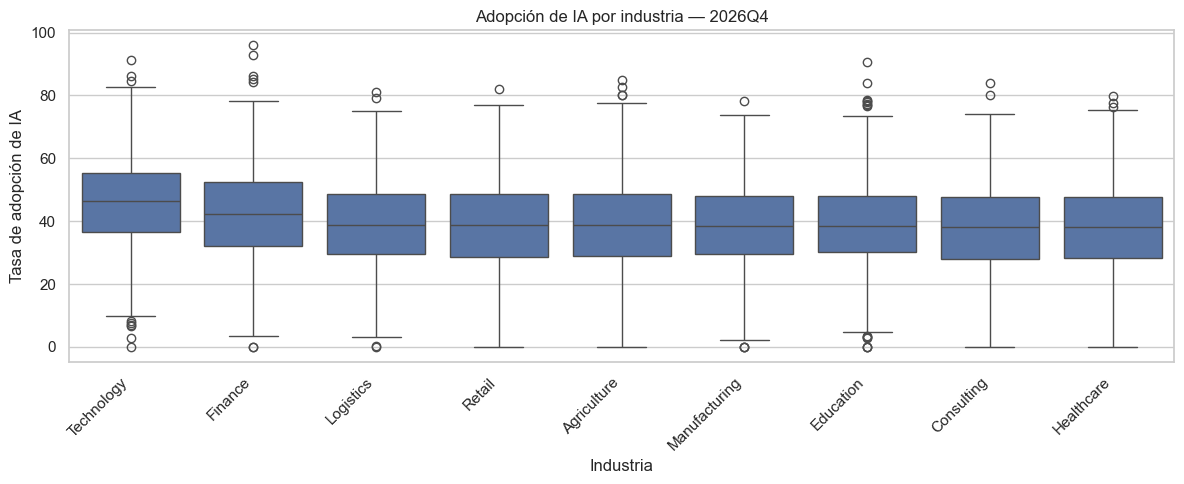

industry
Technology       45.92
Finance          42.38
Education        39.10
Agriculture      38.95
Logistics        38.77
Manufacturing    38.68
Retail           38.65
Healthcare       38.09
Consulting       37.73
Name: ai_adoption_rate, dtype: float64

In [28]:
industry_df = company_limpio.dropna(
    subset=['company_id', 'survey_year', 'quarter',
            'industry', 'ai_adoption_rate']
).copy()

industry_df['period'] = pd.PeriodIndex(
    year=industry_df['survey_year'].astype(int),
    quarter=industry_df['quarter'].str.extract(r'(\d)')[0].astype(int),
    freq='Q'
)

latest_period = industry_df['period'].max()

industry_latest = industry_df[
    industry_df['period'].eq(latest_period)
].copy()

industry_order = (
    industry_latest
    .groupby('industry')['ai_adoption_rate']
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=industry_latest,
    x='industry',
    y='ai_adoption_rate',
    order=industry_order
)

plt.title(f'Adopción de IA por industria — {latest_period}')
plt.xlabel('Industria')
plt.ylabel('Tasa de adopción de IA')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

industry_latest.groupby('industry')['ai_adoption_rate'].mean().sort_values(ascending=False).round(2).head(10)


En el último trimestre común, `Technology` presenta el mayor nivel medio de adopción,
seguida por `Finance`. La distancia entre la industria con mayor y menor promedio es
de alrededor de ocho puntos, por lo que no resulta razonable descartarla como trivial.
Sin embargo, este análisis descriptivo no permite afirmar que la diferencia sea
estadísticamente significativa ni explicar su causa. Una posible línea de análisis
posterior es evaluar si tamaño empresarial, inversión o contexto del país ayudan a
explicar esas brechas sectoriales.

Para complementar el nivel observado en un único trimestre, analizamos ahora la
**velocidad de evolución** de la adopción por industria.


#### Evolución de la adopción mediana de la IA por industria a lo largo del tiempo


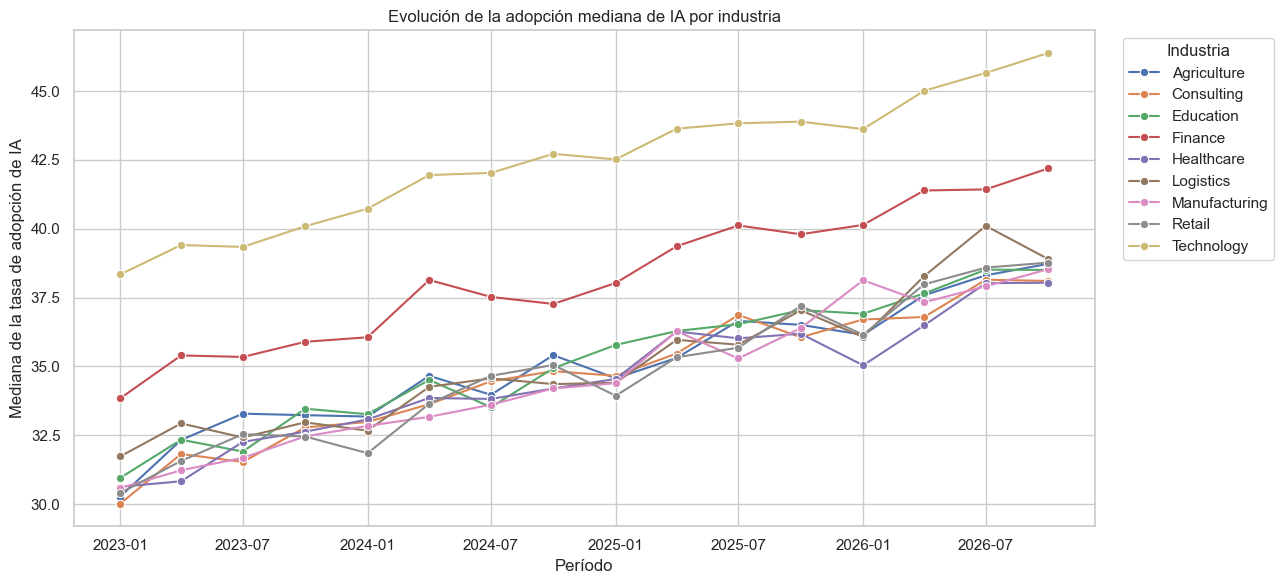

In [29]:
industry_evolution = (
    industry_df
    .groupby(['period', 'industry'])['ai_adoption_rate']
    .agg(
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        companies='count'
    )
    .reset_index()
)

industry_evolution['date'] = (
    industry_evolution['period'].dt.to_timestamp()
)

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=industry_evolution,
    x='date',
    y='median',
    hue='industry',
    marker='o'
)

plt.title('Evolución de la adopción mediana de IA por industria')
plt.xlabel('Período')
plt.ylabel('Mediana de la tasa de adopción de IA')
plt.legend(title='Industria', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


Todas las industrias muestran una trayectoria ascendente y ritmos de crecimiento
visualmente similares. `Technology` y `Finance` mantienen niveles de adopción más
altos durante el período, pero no parecen crecer sustancialmente más rápido que el
resto.

Esto permite distinguir dos ideas: algunos sectores **lideran en nivel**, mientras que
el crecimiento de la adopción parece ser un fenómeno **transversal**. La notebook no
realiza un test formal de diferencias de pendientes, por lo que esta conclusión se
mantiene en el plano descriptivo.


### Inversión en IA por empleado vs cambio de productividad

Se utiliza un único corte temporal para no tratar observaciones repetidas de una misma
empresa como si fueran independientes. Debido a la gran cantidad de puntos, se usa un
`hexbin`, que permite visualizar dónde se concentra la masa de observaciones.


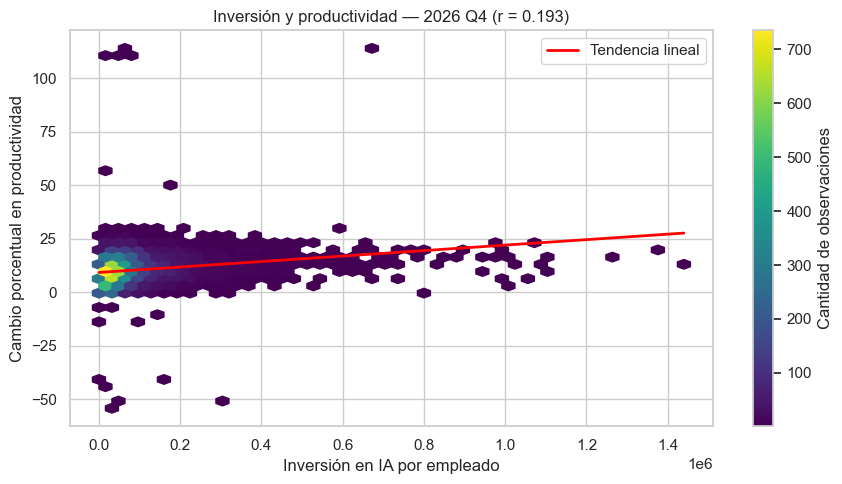

Correlación total: 0.193
Pendiente lineal: 0.000013


In [30]:
panel = company_limpio.dropna(
    subset=[
        'company_id',
        'survey_year',
        'quarter',
        'company_size',
        'ai_investment_per_employee',
        'productivity_change_percent'
    ]
).copy()

panel['quarter_num'] = (
    panel['quarter']
    .str.extract(r'(\d)')[0]
    .astype(int)
)

latest_year = panel['survey_year'].max()
latest_quarter = panel.loc[
    panel['survey_year'].eq(latest_year),
    'quarter_num'
].max()

latest = panel[
    panel['survey_year'].eq(latest_year)
    & panel['quarter_num'].eq(latest_quarter)
    & panel['ai_investment_per_employee'].ge(0)
].copy()

corr_total = latest[
    ['ai_investment_per_employee', 'productivity_change_percent']
].corr().iloc[0, 1]

pendiente_total, intercepto_total = np.polyfit(
    latest['ai_investment_per_employee'],
    latest['productivity_change_percent'],
    1
)

plt.figure(figsize=(9, 5))
hb = plt.hexbin(
    latest['ai_investment_per_employee'],
    latest['productivity_change_percent'],
    gridsize=45,
    mincnt=1,
    cmap='viridis'
)

x_line = np.linspace(
    latest['ai_investment_per_employee'].min(),
    latest['ai_investment_per_employee'].max(),
    100
)
plt.plot(
    x_line,
    pendiente_total * x_line + intercepto_total,
    color='red',
    linewidth=2,
    label='Tendencia lineal'
)

plt.colorbar(hb, label='Cantidad de observaciones')
plt.title(
    f'Inversión y productividad — {int(latest_year)} Q{latest_quarter} '
    f'(r = {corr_total:.3f})'
)
plt.xlabel('Inversión en IA por empleado')
plt.ylabel('Cambio porcentual en productividad')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Correlación total: {corr_total:.3f}')
print(f'Pendiente lineal: {pendiente_total:.6f}')


La asociación es **positiva pero débil**. La pendiente de la tendencia es ascendente,
pero existe una dispersión considerable de productividad para niveles similares de
inversión. Por eso, el gráfico no respalda una interpretación causal: las empresas que
más invierten también pueden diferir en tamaño, madurez tecnológica u otras
características.

Además, se observa una concentración importante de casos en la zona de inversión más
baja. Para comprobar si esa masa actúa como un ancla sobre la relación, repetimos el
cálculo excluyendo únicamente el 10% inferior de inversión del trimestre.


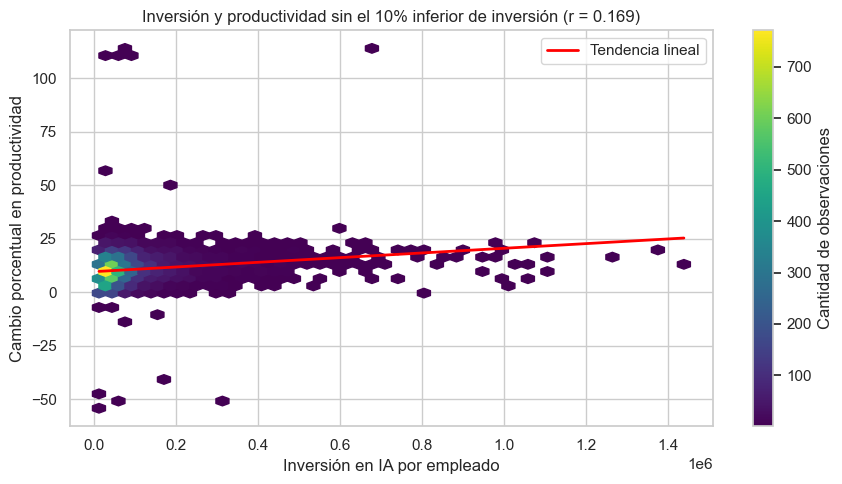

,correlacion_inversion_productividad
company_size,
Enterprise,0.147
SME,0.180
Startup,0.169


Umbral del percentil 10: 10892.42
Correlación original: 0.193
Correlación filtrada: 0.169


In [31]:
# Análisis de sensibilidad: se excluye el 10% inferior de inversión.
umbral_baja_inversion = latest['ai_investment_per_employee'].quantile(0.10)

latest_sin_baja_inversion = latest[
    latest['ai_investment_per_employee'] > umbral_baja_inversion
].copy()

corr_filtrada = latest_sin_baja_inversion[
    ['ai_investment_per_employee', 'productivity_change_percent']
].corr().iloc[0, 1]

pendiente_filtrada, intercepto_filtrada = np.polyfit(
    latest_sin_baja_inversion['ai_investment_per_employee'],
    latest_sin_baja_inversion['productivity_change_percent'],
    1
)

plt.figure(figsize=(9, 5))
hb = plt.hexbin(
    latest_sin_baja_inversion['ai_investment_per_employee'],
    latest_sin_baja_inversion['productivity_change_percent'],
    gridsize=45,
    mincnt=1,
    cmap='viridis'
)

x_line = np.linspace(
    latest_sin_baja_inversion['ai_investment_per_employee'].min(),
    latest_sin_baja_inversion['ai_investment_per_employee'].max(),
    100
)
plt.plot(
    x_line,
    pendiente_filtrada * x_line + intercepto_filtrada,
    color='red',
    linewidth=2,
    label='Tendencia lineal'
)

plt.colorbar(hb, label='Cantidad de observaciones')
plt.title(
    'Inversión y productividad sin el 10% inferior de inversión '
    f'(r = {corr_filtrada:.3f})'
)
plt.xlabel('Inversión en IA por empleado')
plt.ylabel('Cambio porcentual en productividad')
plt.legend()
plt.tight_layout()
plt.show()

# Desagregación breve por tamaño para detectar si la relación está dominada
# por un único tipo de empresa.
corr_por_tamano = (
    latest
    .groupby('company_size')
    .apply(
        lambda g: g[
            ['ai_investment_per_employee', 'productivity_change_percent']
        ].corr().iloc[0, 1],
        include_groups=False
    )
    .rename('correlacion_inversion_productividad')
    .round(3)
)

display(corr_por_tamano.to_frame())
print(f'Umbral del percentil 10: {umbral_baja_inversion:.2f}')
print(f'Correlación original: {corr_total:.3f}')
print(f'Correlación filtrada: {corr_filtrada:.3f}')


Al excluir el 10% inferior de inversión, la relación continúa siendo positiva pero
sigue siendo débil. Por lo tanto, la concentración de observaciones cerca de los
niveles más bajos de inversión **no explica por sí sola** la asociación observada.

La desagregación por `company_size` tampoco muestra una relación fuerte en ninguno de
los grupos. Esto refuerza una lectura prudente: existe asociación, pero no puede
concluirse que aumentar la inversión cause mejoras de productividad. En análisis
posteriores sería necesario controlar simultáneamente por tamaño, industria y otras
variables relevantes.


### Diferencias entre regiones y vínculo país-madurez digital

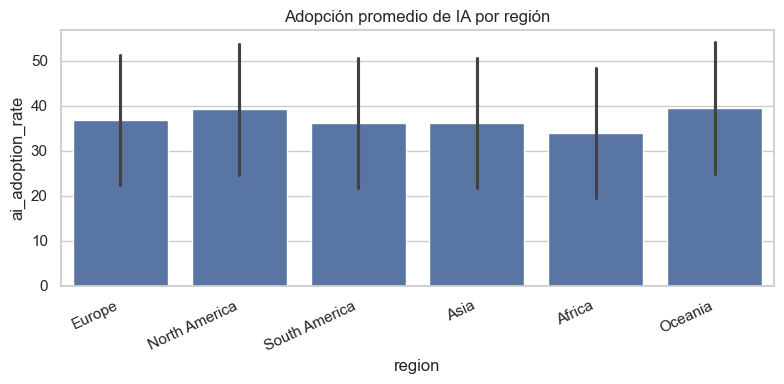

In [32]:
plt.figure(figsize=(8, 4))
# Add error bars representing the standard deviation of ai_adoption_rate within each region
sns.barplot(data=company_limpio, x='region', y='ai_adoption_rate', errorbar='sd', color='C0')
plt.title('Adopción promedio de IA por región')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


La adopción promedio difiere entre regiones, pero también existe dispersión importante
dentro de cada una. Por eso, la región geográfica no debe interpretarse como una
explicación suficiente del fenómeno. En particular, **Asia es un grupo muy
heterogéneo**: reunir países con estructuras económicas y tecnológicas diferentes en
una única categoría regional simplifica una realidad más compleja.

Para evitar quedarnos únicamente con promedios regionales, pasamos al nivel país y lo
relacionamos con el índice de madurez digital.


In [33]:
import plotly.express as px

country_adoption = (
    company
    .groupby('country', as_index=False)['ai_adoption_rate']
    .agg(
        ai_adoption_rate='mean',
        adoption_std='std'
    )
)

country_merged = (
    country_adoption
    .merge(
        country[['country', 'digital_maturity_index', 'region']],
        on='country',
        how='left'
    )
)

correlacion_pais = country_merged[
    ['digital_maturity_index', 'ai_adoption_rate']
].corr().iloc[0, 1]

fig = px.scatter(
    country_merged,
    x='digital_maturity_index',
    y='ai_adoption_rate',
    color='region',
    hover_name='country',
    hover_data={
        'digital_maturity_index': ':.3f',
        'ai_adoption_rate': ':.2f',
        'adoption_std': ':.2f',
        'region': True
    },
    title=(
        'Madurez digital del país vs adopción promedio de IA por región '
        f'(r = {correlacion_pais:.3f})'
    ),
    labels={
        'digital_maturity_index': 'Índice de madurez digital',
        'ai_adoption_rate': 'Tasa promedio de adopción de IA',
        'adoption_std': 'Desvío estándar'
    },
)

fig.update_traces(marker=dict(size=10, opacity=0.7))
fig.show()


El gráfico de dispersión entre el índice de madurez digital y la adopción promedio de IA por país muestra una relación positiva, aunque no perfecta ($r=0.521$). Esto sugiere que los países con mayor madurez digital tienden a presentar una mayor adopción de IA, aunque la relación observada es descriptiva y no implica causalidad.

Existen excepciones relevantes. Algunos países con alta madurez digital presentan una adopción menor de la esperada según la tendencia general, mientras que otros con una madurez digital más baja muestran niveles relativamente altos de adopción. Estos casos sugieren que la madurez digital del país no explica por sí sola el comportamiento de las empresas.

Los puntos se encuentran coloreados por región. Además, al posicionarse sobre cada país puede consultarse el **desvío estándar de la tasa de adopción**, utilizado como medida de la dispersión interna. Se decidió no representarlo mediante barras verticales en el gráfico principal porque su magnitud dificultaba considerablemente la lectura de los promedios por país.

Por último, **Asia debe interpretarse con cautela**. La región agrupa países muy heterogéneos en términos económicos y tecnológicos, por lo que no resulta apropiado generalizar el comportamiento de toda la región a partir de un único patrón.

## 6) Análisis de probabilidad

Hasta aquí analizamos distribuciones, tendencias y asociaciones. Como complemento,
incorporamos una mirada de **probabilidad descriptiva** para responder dos preguntas:

1. ¿Los niveles altos de adopción, madurez y productividad tienden a aparecer juntos?
2. ¿Cómo cambia la probabilidad de una mejora importante de productividad entre
   empresas con niveles bajos y altos de adopción de IA?

Para evitar mezclar los distintos períodos de una misma empresa como si fueran
observaciones independientes, este bloque utiliza únicamente el **último período
disponible (2026 Q2)**. De esta manera, cada empresa aporta como máximo una observación.

### 6.1) ¿Los niveles altos de adopción, madurez y productividad se concentran?

Definimos como “alto” estar por encima del tercer cuartil (Q3) de cada variable dentro
del último período. Luego calculamos la proporción de empresas que se encuentra
simultáneamente en el cuarto superior de:

- `ai_adoption_rate`
- `ai_maturity_score`
- `productivity_change_percent`

Como referencia descriptiva, si estos tres eventos fueran independientes, la
intersección esperada sería $0.25^3 = 1.56\%$.

Esta comparación **no es un test estadístico**: funciona únicamente como referencia
para evaluar cuánto se superponen los grupos de valores altos.

In [34]:
# Último período disponible: una observación por empresa.
prob_df = company_limpio.dropna(
    subset=[
        'company_id',
        'survey_year',
        'quarter',
        'ai_adoption_rate',
        'ai_maturity_score',
        'productivity_change_percent'
    ]
).copy()

prob_df['quarter_num'] = (
    prob_df['quarter']
    .str.extract(r'(\d)')[0]
    .astype(int)
)

prob_year = prob_df['survey_year'].max()
prob_quarter = prob_df.loc[
    prob_df['survey_year'].eq(prob_year),
    'quarter_num'
].max()-2 # Se analiza el Q2 de 2026

prob_latest = prob_df[
    prob_df['survey_year'].eq(prob_year)
    & prob_df['quarter_num'].eq(prob_quarter)
].copy()

variables_q3 = [
    'ai_adoption_rate',
    'ai_maturity_score',
    'productivity_change_percent'
]

q3 = prob_latest[variables_q3].quantile(0.75)

arriba_todas = (
    (prob_latest['ai_adoption_rate'] > q3['ai_adoption_rate'])
    & (prob_latest['ai_maturity_score'] > q3['ai_maturity_score'])
    & (
        prob_latest['productivity_change_percent']
        > q3['productivity_change_percent']
    )
)

probabilidad_conjunta = arriba_todas.mean()
referencia_independencia = 0.25 ** 3

print(f'Período analizado: {int(prob_year)} Q{prob_quarter}')
print(f'Empresas analizadas: {len(prob_latest):,}')
print(
    'P(arriba de Q3 en adopción, madurez y productividad): '
    f'{probabilidad_conjunta * 100:.2f}%'
)
print(
    'Referencia si los tres eventos fueran independientes: '
    f'{referencia_independencia * 100:.2f}%'
)

Período analizado: 2026 Q2
Empresas analizadas: 9,240
P(arriba de Q3 en adopción, madurez y productividad): 11.93%
Referencia si los tres eventos fueran independientes: 1.56%


La proporción observada es cercana al **12%**, frente al **1,56%** que resultaría
como referencia bajo independencia. Esto muestra una superposición considerable:
las empresas ubicadas en niveles altos de adopción y madurez aparecen con frecuencia
también entre las de mayor mejora de productividad.

Sin embargo, este resultado debe interpretarse con cautela. `ai_adoption_rate` y
`ai_maturity_score` ya mostraron una asociación fuerte entre sí, por lo que parte de
esta concentración es consistente con la redundancia parcial entre ambas medidas.
El resultado describe un patrón conjunto; **no demuestra causalidad**.

### 6.2) Probabilidad de una mejora grande de productividad por cuartil

Ahora dividimos tres variables vinculadas con la adopción en cuatro grupos de tamaño
similar, desde Q1 (valores bajos) hasta Q4 (valores altos), y calculamos dentro de cada
grupo la proporción de empresas cuya mejora de productividad supera el **20%**.

El umbral del 20% se utiliza como criterio exploratorio para representar una mejora
claramente elevada sin trabajar con un evento excesivamente raro. Nuevamente, el
análisis se realiza sólo sobre **2026 Q2**.

In [35]:
UMBRAL = 20

def prob_por_cuartil(df, variable, umbral=UMBRAL):
    """Calcula P(productividad > umbral) dentro de cada cuartil."""
    d = df.dropna(
        subset=[variable, 'productivity_change_percent']
    ).copy()

    d['grupo'] = pd.qcut(
        d[variable],
        4,
        labels=['Q1 (bajo)', 'Q2', 'Q3', 'Q4 (alto)'],
        duplicates='drop'
    )

    prob = (
        d.groupby('grupo', observed=True)['productivity_change_percent']
        .apply(lambda s: (s > umbral).mean() * 100)
    )

    return prob.round(2)


vars_ia = [
    'ai_adoption_rate',
    'ai_maturity_score',
    'years_using_ai'
]

tabla_prob = pd.DataFrame({
    variable: prob_por_cuartil(prob_latest, variable)
    for variable in vars_ia
})

tabla_prob.index.name = 'Cuartil'

print(
    f'P(mejora de productividad > {UMBRAL}%) '
    f'por cuartil — {int(prob_year)} Q{prob_quarter}'
)

tabla_prob

P(mejora de productividad > 20%) por cuartil — 2026 Q2


,ai_adoption_rate,ai_maturity_score,years_using_ai
Cuartil,,,
Q1 (bajo),0.13,0.17,4.73
Q2,0.52,0.35,4.31
Q3,2.85,2.16,4.54
Q4 (alto),14.77,15.80,4.65


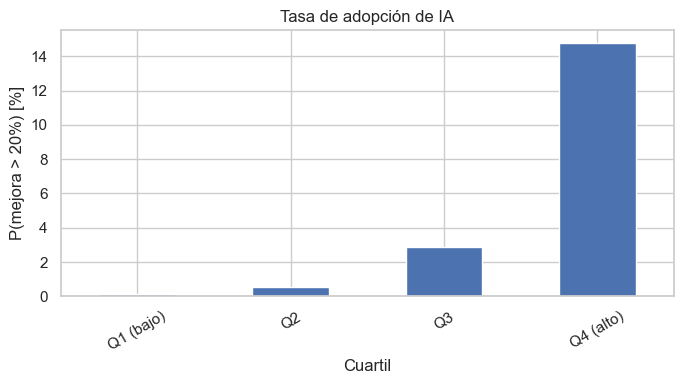

In [36]:
ax = prob_por_cuartil(
    prob_latest,
    'ai_adoption_rate'
).plot(
    kind='bar',
    figsize=(7, 4),
    color='#4C72B0'
)

ax.set_title('Tasa de adopción de IA')
ax.set_xlabel('Cuartil')
ax.set_ylabel(f'P(mejora > {UMBRAL}%) [%]')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

La diferencia entre los extremos es marcada: la probabilidad de superar una mejora
del 20% pasa de aproximadamente **0,13% en Q1** a **14,77% en Q4**. En este corte
temporal, las empresas con mayores tasas de adopción presentan con mucha más frecuencia
mejoras elevadas de productividad.

El patrón es una **asociación descriptiva**. No permite afirmar que aumentar la tasa de
adopción sea, por sí solo, la causa del aumento de productividad.

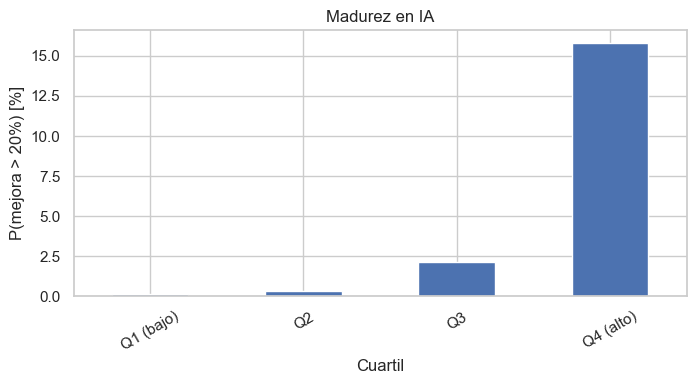

In [37]:
ax = prob_por_cuartil(
    prob_latest,
    'ai_maturity_score'
).plot(
    kind='bar',
    figsize=(7, 4),
    color='#4C72B0'
)

ax.set_title('Madurez en IA')
ax.set_xlabel('Cuartil')
ax.set_ylabel(f'P(mejora > {UMBRAL}%) [%]')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Para `ai_maturity_score` el patrón es similar: la probabilidad pasa de
aproximadamente **0,17% en Q1** a **15,80% en Q4**. La madurez aparece, por lo tanto,
fuertemente asociada con la presencia de mejoras elevadas de productividad.

Este resultado también es coherente con la fuerte relación ya observada entre madurez
y tasa de adopción, por lo que no conviene interpretar ambas variables como explicaciones
completamente independientes.

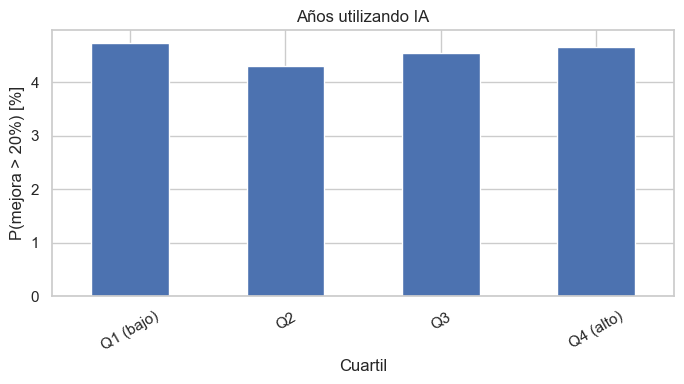

In [38]:
ax = prob_por_cuartil(
    prob_latest,
    'years_using_ai'
).plot(
    kind='bar',
    figsize=(7, 4),
    color='#4C72B0'
)

ax.set_title('Años utilizando IA')
ax.set_xlabel('Cuartil')
ax.set_ylabel(f'P(mejora > {UMBRAL}%) [%]')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

En `years_using_ai` la diferencia es mucho menor: la probabilidad se mueve
aproximadamente entre **4,73% y 4,65%** desde los grupos bajos hacia los altos.

Comparado con adopción y madurez, la antigüedad de uso parece discriminar mucho menos
entre empresas con y sin grandes mejoras de productividad. Esto sugiere una pregunta
interesante para etapas posteriores: podría importar más **cómo de extendida y madura
es la adopción** que simplemente cuántos años lleva una empresa utilizando IA.

### 6.3) Etapa de adopción y mejoras de productividad

Como verificación adicional, podemos observar la misma probabilidad según
`ai_adoption_stage`. Este análisis también sirve para comprobar que la categoría
`none`, conservada durante la limpieza, se comporta de manera coherente con una etapa
de adopción muy baja.

In [39]:
stage_prob = (
    company_limpio[
        company_limpio['survey_year'].eq(prob_year)
        & company_limpio['quarter'].eq(f'Q{prob_quarter}')
    ]
    .dropna(
        subset=['ai_adoption_stage', 'productivity_change_percent']
    )
    .groupby('ai_adoption_stage')['productivity_change_percent']
    .apply(lambda s: (s > UMBRAL).mean() * 100)
    .sort_values()
    .round(2)
)

stage_prob.to_frame(
    name=f'P(productividad > {UMBRAL}%)'
)

,P(productividad > 20%)
ai_adoption_stage,
none,0.00
pilot,0.23
partial,6.31
full,43.51


La etapa `full` presenta una probabilidad muy superior de superar el 20% de mejora de
productividad, mientras que `pilot` y `none` se ubican en niveles muy bajos. Esto es
coherente con los análisis anteriores y, además, refuerza la decisión de conservar
`none` como **categoría válida** en lugar de tratarla como un dato faltante.

### Conclusión del análisis de probabilidad

Los tres enfoques cuentan una historia consistente: en el período **2026 Q2**, los niveles
altos de adopción y madurez tienden a coincidir con mejoras elevadas de productividad,
mientras que la cantidad de años utilizando IA muestra una diferencia mucho menor.

El análisis sigue siendo **exploratorio y observacional**. Las probabilidades calculadas
son frecuencias observadas dentro de la muestra y no prueban relaciones causales. Su
valor principal es ayudar a formular hipótesis concretas para los siguientes prácticos.

## 7) Hipótesis de investigación

A partir de los patrones observados se formulan tres preguntas concretas que pueden
retomarse en los prácticos siguientes:

### H1 — Inversión en IA y productividad

**Pregunta:** ¿Las empresas con mayor inversión en IA por empleado muestran mayores
mejoras de productividad, controlando por industria y tamaño empresarial?

**Motivación:** en el último trimestre se observa una asociación positiva pero débil,
que se mantiene aun al excluir el 10% inferior de inversión. La relación podría estar
condicionada por características de las empresas.

**Cómo abordarla después:** modelar `productivity_change_percent` usando
`ai_investment_per_employee` e incorporar al menos `industry` y `company_size` como
variables de control.

### H2 — Industria y nivel de adopción

**Pregunta:** ¿Las diferencias de nivel de adopción de IA entre industrias se mantienen
una vez consideradas características como tamaño empresarial y país?

**Motivación:** `Technology` y `Finance` lideran en nivel, aunque las industrias muestran
trayectorias de crecimiento similares. Esto sugiere separar el efecto del nivel inicial
de la velocidad de adopción.

**Cómo abordarla después:** comparar industrias controlando por período, tamaño y
contexto geográfico, en lugar de atribuir las diferencias únicamente al sector.

### H3 — IA y transformación del empleo

**Pregunta:** ¿Una mayor adopción de IA se relaciona con destrucción neta de empleo o
con transformación de puestos de trabajo?

**Motivación:** el dataset contiene `jobs_created`, `jobs_displaced` y
`reskilled_employees`, lo que permite estudiar no solo pérdida de puestos sino también
creación y reconversión laboral.

**Cómo abordarla después:** construir un balance simple, por ejemplo
`jobs_created - jobs_displaced`, y analizar su relación con `ai_adoption_rate`,
`task_automation_rate`, industria y tamaño empresarial.


## 8) Conclusiones parciales

El análisis exploratorio muestra que la adopción de IA presenta diferencias de nivel
entre industrias y regiones, pero también un crecimiento temporal extendido entre
sectores. `Technology` y `Finance` aparecen entre los sectores con mayor adopción,
aunque el crecimiento no parece exclusivo de ellos. A nivel país, la madurez digital
se asocia positivamente con la adopción promedio, pero existen excepciones y una
importante dispersión interna que impiden reducir el fenómeno a una sola explicación
geográfica.

La inversión en IA por empleado presenta una relación positiva pero débil con el cambio
de productividad. Esa relación persiste al controlar de forma descriptiva la
concentración de inversiones muy bajas y no parece estar dominada por un único tamaño
de empresa. Por tratarse de un EDA, estos resultados se interpretan como asociaciones
y no como evidencia causal. Las preguntas abiertas sobre productividad, diferencias
sectoriales y transformación del empleo quedan formuladas como hipótesis concretas
para análisis posteriores.


El análisis de probabilidad complementa estos resultados: al trabajar únicamente con
el último período, los niveles altos de adopción y madurez aparecen asociados con una
mayor frecuencia de mejoras de productividad superiores al 20%, mientras que los años
de uso muestran diferencias mucho menores. Este patrón refuerza el interés de estudiar
la **intensidad y madurez de la adopción**, sin interpretarlo todavía como evidencia
causal.